In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from scipy.stats import lognorm

In [4]:
# Specify the parameters of the distrubtion
c               = -2.0915784326697198
alpha           = 1.0099919011379082
beta            = 1.0266672599410456
std_residuals   = 0.4220842476334173

In [5]:
# Specify the maximal acceptable error
max_acceptable_error = 0.0192 # Value found in the paper, can be changed by the user
# max_acceptable_error = 0.03 # Example of changing the value

# Case one: existing application

We will consider how to study the maximal error in the case that an Expected Threat model is already in use. To illustrate this, we will use the situation of the Expected Threat model by Karun Singh (2018) in hist blog post.<br>
In this example we have $M=192$ and $N=620,000$.

In [6]:
# Number of states/squares in the model
M = 192

# Number of training data points
N = 620_000 

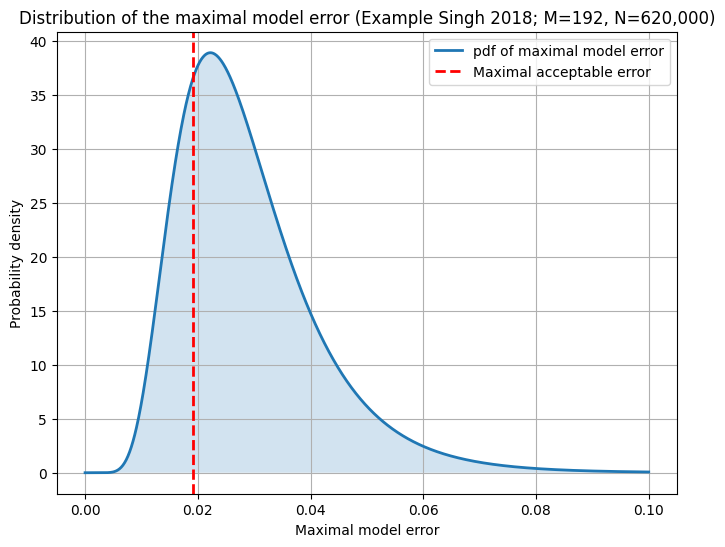

In [7]:
# Plot the distribution
plt.figure(figsize=(8, 6))
x = np.linspace(0, 0.1, 1000)
y = lognorm.pdf(x=x, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
plt.plot(x, y, lw=2, label='pdf of maximal model error')
plt.axvline(max_acceptable_error, color='red', linestyle='--', lw=2, label='Maximal acceptable error')
plt.fill_between(x, y, alpha=0.2)

plt.xlabel('Maximal model error')
plt.ylabel('Probability density')
plt.title(f'Distribution of the maximal model error (Example Singh 2018; M=192, N=620,000)')
plt.legend()
plt.grid()

plt.show()

In [8]:
prob_acceptable_error = lognorm.cdf(max_acceptable_error, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
print(f'Probability of acceptable error: {prob_acceptable_error:.4f}')

Probability of acceptable error: 0.2209


<>:36: SyntaxWarning: invalid escape sequence '\w'
<>:36: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_23188\2301422951.py:36: SyntaxWarning: invalid escape sequence '\w'
  plt.xlabel('Model error ($||xT-\widehat{xT}||_{\infty})$')


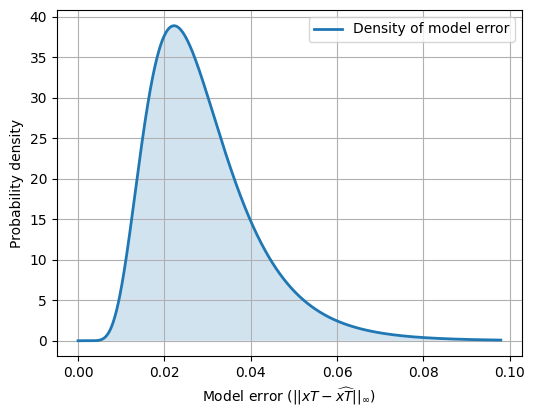

In [14]:
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 3.0

# Plot the distribution
plt.figure(figsize=(6, 4.5))

percentile_0999 = lognorm.ppf(0.999, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
x = np.linspace(0, percentile_0999, 1000)
y = lognorm.pdf(x=x, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
plt.plot(x, y, lw=2, label='Density of model error')

plt.fill_between(x, y, alpha=0.2)

# plt.axvline(max_acceptable_error, color='red', linestyle='--', lw=2, label='Maximal acceptable error (0.03)')

# plt.fill_between(x, y, max_acceptable_error, 
#                  where=(x < max_acceptable_error), 
#                  alpha=0.7, 
#                  facecolor='none', 
#                  hatch='//',
#                  edgecolor='green',    
#                 #  edgelinewidth=5,           
#                  )


# percentile_099 = lognorm.ppf(0.99, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
# prob_acceptable_error = lognorm.cdf(max_acceptable_error, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
# x_ = min(x[np.argmax(y)], max_acceptable_error * 0.8)
# y_ = lognorm.pdf(x_, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))/2
# plt.annotate(f'Probability of\nacceptable error: \n{prob_acceptable_error:.4f}',
#              xy=(x_, y_),
#              xytext=(percentile_099, np.max(y)*0.66),
#              arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
#              )

plt.xlabel('Model error ($||xT-\widehat{xT}||_{\infty})$')
plt.ylabel('Probability density')
# plt.title(f'Distribution of the maximal model error (Example Singh 2018; M=192, N=620,000)')
plt.legend()
plt.grid()

plt.show()

<>:35: SyntaxWarning: invalid escape sequence '\w'
<>:35: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_23188\355257735.py:35: SyntaxWarning: invalid escape sequence '\w'
  plt.xlabel('Model error ($||xT-\widehat{xT}||_{\infty})$')


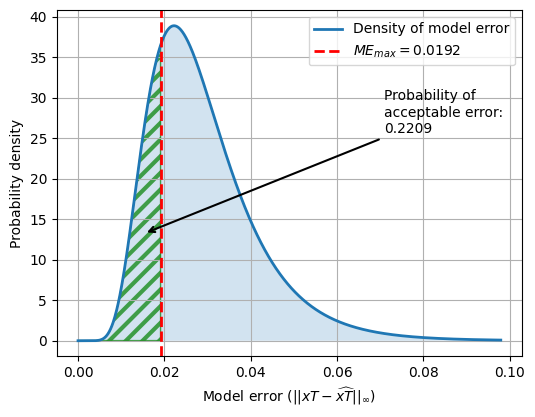

In [16]:
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 3.0

# Plot the distribution
plt.figure(figsize=(6, 4.5))

percentile_0999 = lognorm.ppf(0.999, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
x = np.linspace(0, percentile_0999, 1000)
y = lognorm.pdf(x=x, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
plt.plot(x, y, lw=2, label='Density of model error')

plt.fill_between(x, y, alpha=0.2)

plt.axvline(max_acceptable_error, color='red', linestyle='--', lw=2, label=rf'$ME_{{max}}={max_acceptable_error:.4f}$')
plt.fill_between(x, y, max_acceptable_error, 
                 where=(x < max_acceptable_error), 
                 alpha=0.7, 
                 facecolor='none', 
                 hatch='//',
                 edgecolor='green',    
                #  edgelinewidth=5,           
                 )


percentile_099 = lognorm.ppf(0.99, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
prob_acceptable_error = lognorm.cdf(max_acceptable_error, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
x_ = min(x[np.argmax(y)], max_acceptable_error * 0.8)
y_ = lognorm.pdf(x_, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))/2
plt.annotate(f'Probability of\nacceptable error: \n{prob_acceptable_error:.4f}',
             xy=(x_, y_),
             xytext=(percentile_099, np.max(y)*0.66),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             )

plt.xlabel('Model error ($||xT-\widehat{xT}||_{\infty})$')
plt.ylabel('Probability density')
# plt.title(f'Distribution of the maximal model error (Example Singh 2018; M=192, N=620,000)')
plt.legend()
plt.grid()

plt.show()

<>:40: SyntaxWarning: invalid escape sequence '\w'
<>:40: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_23188\3864766136.py:40: SyntaxWarning: invalid escape sequence '\w'
  plt.xlabel('Model error ($||xT-\widehat{xT}||_{\infty})$')


The model error has a lognormal(-3.6281, 0.4221) distribution
The model error has a lognormal distribution with mu=0.0266 and sigma=0.4221
Mean of the maximal model error: 0.0290


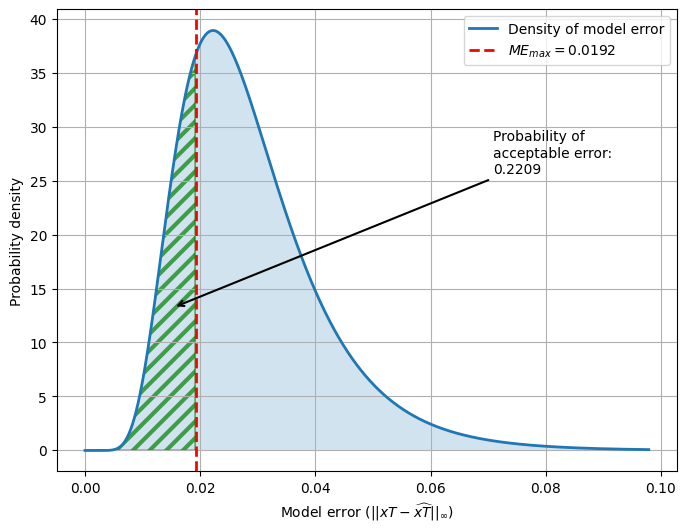

In [12]:
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 3.0

# Plot the distribution
plt.figure(figsize=(8, 6))

percentile_0999 = lognorm.ppf(0.999, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
x = np.linspace(0, percentile_0999, 1000)
y = lognorm.pdf(x=x, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
plt.plot(x, y, lw=2, label='Density of model error')

plt.fill_between(x, y, alpha=0.2)

plt.axvline(max_acceptable_error, color='red', linestyle='--', lw=2, label=rf'$ME_{{max}}={max_acceptable_error:.4f}$')

plt.fill_between(x, y, max_acceptable_error, 
                 where=(x < max_acceptable_error), 
                 alpha=0.7, 
                 facecolor='none', 
                 hatch='//',
                 edgecolor='green',    
                #  edgelinewidth=5,           
                 )


percentile_099 = lognorm.ppf(0.99, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
prob_acceptable_error = lognorm.cdf(max_acceptable_error, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
print(f"The model error has a lognormal({c + alpha*np.log(M) - beta*np.log(np.sqrt(N)):.4f}, {std_residuals:.4f}) distribution")
print(f"The model error has a lognormal distribution with mu={np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))):.4f} and sigma={std_residuals:.4f}")
x_ = min(x[np.argmax(y)], max_acceptable_error * 0.8)
y_ = lognorm.pdf(x_, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))/2
plt.annotate(f'Probability of\nacceptable error: \n{prob_acceptable_error:.4f}',
             xy=(x_, y_),
             xytext=(percentile_099, np.max(y)*0.66),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             )

print(f"Mean of the maximal model error: {lognorm.mean(s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N)))):.4f}")

plt.xlabel('Model error ($||xT-\widehat{xT}||_{\infty})$')
plt.ylabel('Probability density')
# plt.title(f'Distribution of the maximal model error (Example Singh 2018; M=192, N=620,000)')
plt.legend()
plt.grid()

plt.show()

# Case two: Given a data set, find grid size

In [93]:
number_of_data_points = 2_480_000
# number_of_data_points = 3_000_000

desired_certainty = 0.9
# desired_certainty = 0.75 

# Specify the ratio between the number of discretization points in the x and y directions
nx_ny_ratio = 3/4

# Specify the minimal number of descretization points in the x-direction
min_nx = 6 # Corresponds to (6x5) grid
max_nx = 32 # Corresponds to (32x24) grid


In [94]:
nxs = np.arange(min_nx, max_nx+1)
nys = np.ceil(nx_ny_ratio*nxs).astype(int)

print([(int(nxs[i]), int(nys[i])) for i in range(len(nxs))])

Ms = nxs * nys

Ms = Ms[Ms < 500]

[(6, 5), (7, 6), (8, 6), (9, 7), (10, 8), (11, 9), (12, 9), (13, 10), (14, 11), (15, 12), (16, 12), (17, 13), (18, 14), (19, 15), (20, 15), (21, 16), (22, 17), (23, 18), (24, 18), (25, 19), (26, 20), (27, 21), (28, 21), (29, 22), (30, 23), (31, 24), (32, 24)]


Max M with acceptable error: 80
Corresponding nx: 10
Corresponding ny: 8


<>:33: SyntaxWarning: invalid escape sequence '\w'
<>:33: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_9664\3752434960.py:33: SyntaxWarning: invalid escape sequence '\w'
  plt.ylabel('Maximal model error ($||xT-\widehat{xT}||_{\infty})$)')


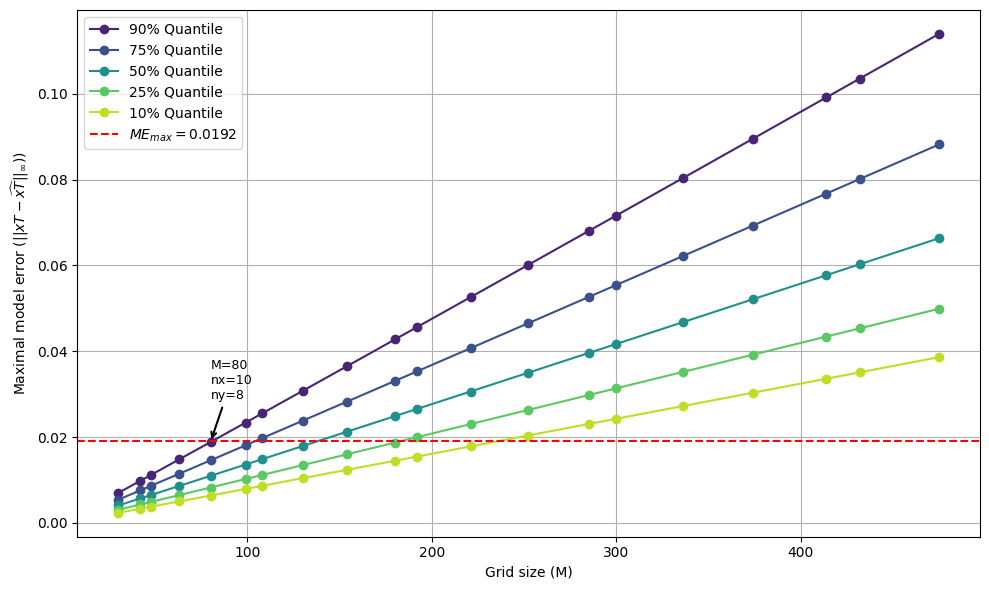

In [95]:
plt.figure(figsize=(10, 6))

# Define the quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if not desired_certainty in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

# Plot the quantiles
for q in quantiles:
    qs = lognorm.ppf(q, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))
    plt.plot(Ms, qs, label=f'{int(q*100)}% Quantile', marker='o', color=cm.viridis_r(q))

qs = lognorm.ppf(desired_certainty, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))

# Get the index of the largest M below max_max_error
index = np.argwhere(qs < max_acceptable_error)[-1][0]
# Get the corresponding M, nx, and ny values
M = Ms[index]
n_x = nxs[index]
n_y = nys[index]
print(f"Max M with acceptable error: {M}")
print(f"Corresponding nx: {n_x}")
print(f"Corresponding ny: {n_y}")

# Annotate the largest M below max_max_error
plt.annotate(f'M={int(M)}\nnx={int(n_x)}\nny={int(n_y)}', xy=(M, qs[index]), xytext=(M, qs[index]+0.01),
             arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black')

# Add horizontal line at max_max_error
plt.axhline(y=max_acceptable_error, color='red', linestyle='--', label=rf'$ME_{{max}}={max_acceptable_error:.4f}$')
plt.xlabel('Grid size (M)')
plt.ylabel('Maximal model error ($||xT-\widehat{xT}||_{\infty})$)')
# plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
# plt.xticks(Ms, rotation=90)
plt.show()


<>:33: SyntaxWarning: invalid escape sequence '\w'
<>:33: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_9664\846244445.py:33: SyntaxWarning: invalid escape sequence '\w'
  plt.ylabel('Maximal model error ($||xT-\widehat{xT}||_{\infty})$)')


Max M with acceptable error: 80
Corresponding nx: 10
Corresponding ny: 8


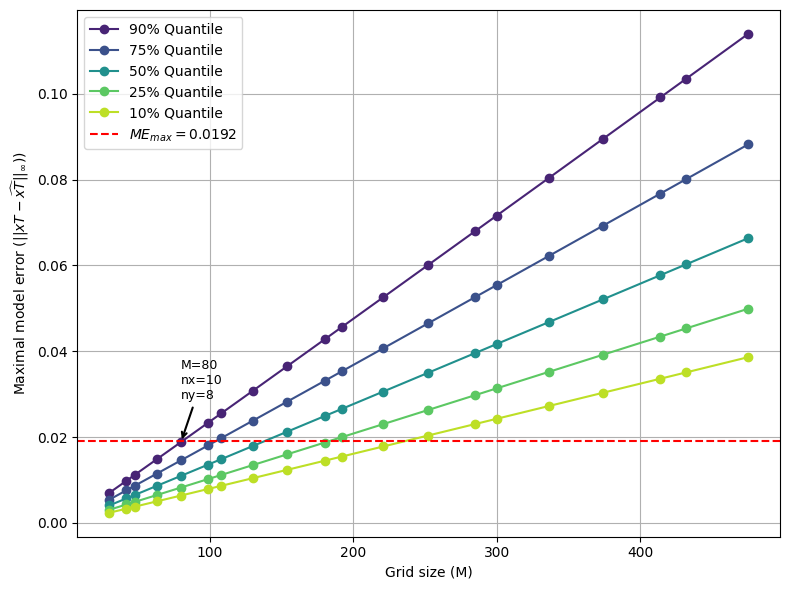

In [96]:
plt.figure(figsize=(8, 6))

# Define the quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if not desired_certainty in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

# Plot the quantiles
for q in quantiles:
    qs = lognorm.ppf(q, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))
    plt.plot(Ms, qs, label=f'{int(q*100)}% Quantile', marker='o', color=cm.viridis_r(q))

qs = lognorm.ppf(desired_certainty, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))

# Get the index of the largest M below max_max_error
index = np.argwhere(qs < max_acceptable_error)[-1][0]
# Get the corresponding M, nx, and ny values
M = Ms[index]
n_x = nxs[index]
n_y = nys[index]
print(f"Max M with acceptable error: {M}")
print(f"Corresponding nx: {n_x}")
print(f"Corresponding ny: {n_y}")

# Annotate the largest M below max_max_error
plt.annotate(f'M={int(M)}\nnx={int(n_x)}\nny={int(n_y)}', xy=(M, qs[index]), xytext=(M, qs[index]+0.01),
             arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black')

# Add horizontal line at max_max_error
plt.axhline(y=max_acceptable_error, color='red', linestyle='--', label=rf'$ME_{{max}}={max_acceptable_error}$')
plt.xlabel('Grid size (M)')
plt.ylabel('Maximal model error ($||xT-\widehat{xT}||_{\infty})$)')
# plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
# plt.xticks(Ms, rotation=90)
plt.show()


<>:15: SyntaxWarning: invalid escape sequence '\w'
<>:15: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_9664\3689685087.py:15: SyntaxWarning: invalid escape sequence '\w'
  plt.ylabel('Maximal model error ($||xT-\widehat{xT}||_{\infty})$)')


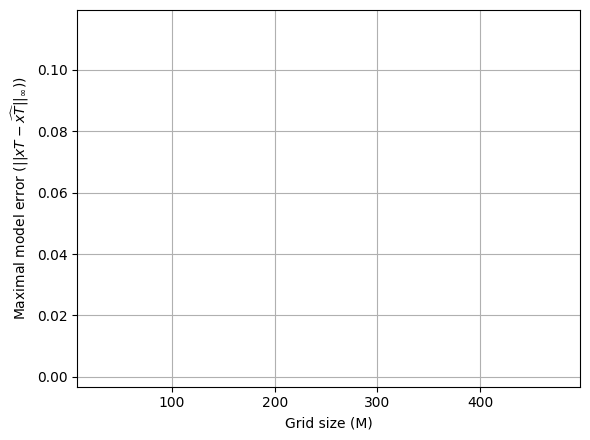

In [97]:
plt.figure(figsize=(6, 4.5))

# Define quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if desired_certainty not in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

# Plot quantiles invisibly to preserve axis limits
for q in quantiles:
    qs = lognorm.ppf(q, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))
    plt.plot(Ms, qs, alpha=0)  # invisible plot to preserve limits

plt.xlabel('Grid size (M)')
plt.ylabel('Maximal model error ($||xT-\widehat{xT}||_{\infty})$)')
plt.grid(True)
plt.tight_layout()
plt.show()


<>:33: SyntaxWarning: invalid escape sequence '\w'
<>:33: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_9664\743351396.py:33: SyntaxWarning: invalid escape sequence '\w'
  plt.ylabel('Model error ($||xT-\widehat{xT}||_{\infty})$)')


Max M with acceptable error: 80
Corresponding nx: 10
Corresponding ny: 8


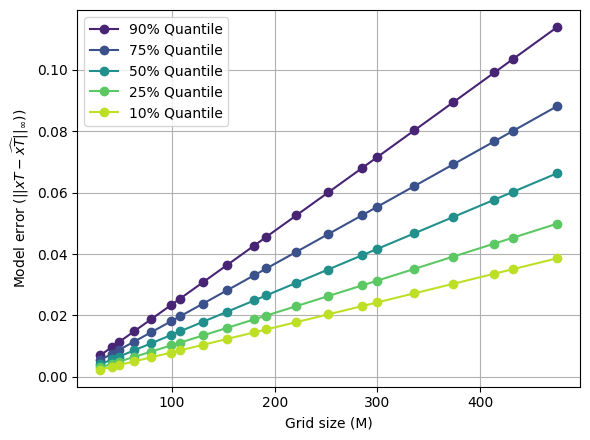

In [98]:
plt.figure(figsize=(6, 4.5))

# Define the quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if not desired_certainty in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

# Plot the quantiles
for q in quantiles:
    qs = lognorm.ppf(q, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))
    plt.plot(Ms, qs, label=f'{int(q*100)}% Quantile', marker='o', color=cm.viridis_r(q))

qs = lognorm.ppf(desired_certainty, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))

# Get the index of the largest M below max_max_error
index = np.argwhere(qs < max_acceptable_error)[-1][0]
# Get the corresponding M, nx, and ny values
M = Ms[index]
n_x = nxs[index]
n_y = nys[index]
print(f"Max M with acceptable error: {M}")
print(f"Corresponding nx: {n_x}")
print(f"Corresponding ny: {n_y}")

# # Annotate the largest M below max_max_error
# plt.annotate(f'M={int(M)}\nnx={int(n_x)}\nny={int(n_y)}', xy=(M, qs[index]), xytext=(M, qs[index]+0.01),
#              arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black')

# Add horizontal line at max_max_error
# plt.axhline(y=max_acceptable_error, color='red', linestyle='--', label='Maximal acceptable error (0.03)')
plt.xlabel('Grid size (M)')
plt.ylabel('Model error ($||xT-\widehat{xT}||_{\infty})$)')
# plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
# plt.xticks(Ms, rotation=90)
plt.show()


<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\w'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_9664\3275957216.py:27: SyntaxWarning: invalid escape sequence '\m'
  plt.annotate(f'$\mathbf{{M={int(M)}}}$\n$\mathbf{{n_x={int(n_x)}}}$\n$\mathbf{{n_y={int(n_y)}}}$', xy=(M, qs[index]), xytext=(M, qs[index]+0.02),
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_9664\3275957216.py:27: SyntaxWarning: invalid escape sequence '\m'
  plt.annotate(f'$\mathbf{{M={int(M)}}}$\n$\mathbf{{n_x={int(n_x)}}}$\n$\mathbf{{n_y={int(n_y)}}}$', xy=(M, qs[index]), xytext=(M, qs[index]+0.02),
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_9664\3275957216.py

Max M with acceptable error: 80
Corresponding nx: 10
Corresponding ny: 8


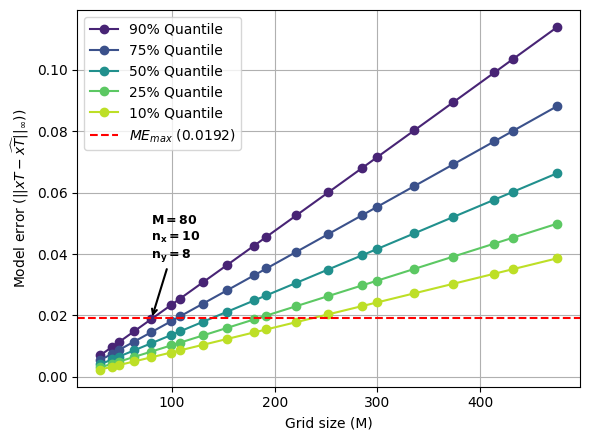

In [104]:
plt.figure(figsize=(6, 4.5))

# Define the quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if not desired_certainty in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

# Plot the quantiles
for q in quantiles:
    qs = lognorm.ppf(q, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))
    plt.plot(Ms, qs, label=f'{int(q*100)}% Quantile', marker='o', color=cm.viridis_r(q))

qs = lognorm.ppf(desired_certainty, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))

# Get the index of the largest M below max_max_error
index = np.argwhere(qs < max_acceptable_error)[-1][0]
# Get the corresponding M, nx, and ny values
M = Ms[index]
n_x = nxs[index]
n_y = nys[index]
print(f"Max M with acceptable error: {M}")
print(f"Corresponding nx: {n_x}")
print(f"Corresponding ny: {n_y}")

# Annotate the largest M below max_max_error
plt.annotate(f'$\mathbf{{M={int(M)}}}$\n$\mathbf{{n_x={int(n_x)}}}$\n$\mathbf{{n_y={int(n_y)}}}$', xy=(M, qs[index]), xytext=(M, qs[index]+0.02),
             arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black', weight='bold')

# Add horizontal line at max_max_error
plt.axhline(y=max_acceptable_error, color='red', linestyle='--', label=rf'$ME_{{max}}$ ({max_acceptable_error:.4f})')
plt.xlabel('Grid size (M)')
plt.ylabel('Model error ($||xT-\widehat{xT}||_{\infty})$)')
# plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
# plt.xticks(Ms, rotation=90)
plt.show()


# Case three: Given a grid size, find data set size

In [64]:
# Specify desired grid
n_x = 16 # 24
n_y = 12 # 18

M = n_x * n_y
print(f"Grid size (M): {M}")

Ns = np.linspace(100_000, 10_000_000, 9000, endpoint=False)
Ns = np.arange(100_000, 10_000_000, 1_000)

Grid size (M): 192


<>:30: SyntaxWarning: invalid escape sequence '\w'
<>:30: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_9664\112357534.py:30: SyntaxWarning: invalid escape sequence '\w'
  plt.ylabel('Model error ($||xT-\widehat{xT}||_{\infty})$)')
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_9664\112357534.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.annotate(f'N={int(N):,}', xy=(N, qs[index]), xytext=(N, qs[index]+0.01),


Min N with acceptable error: [3348000]


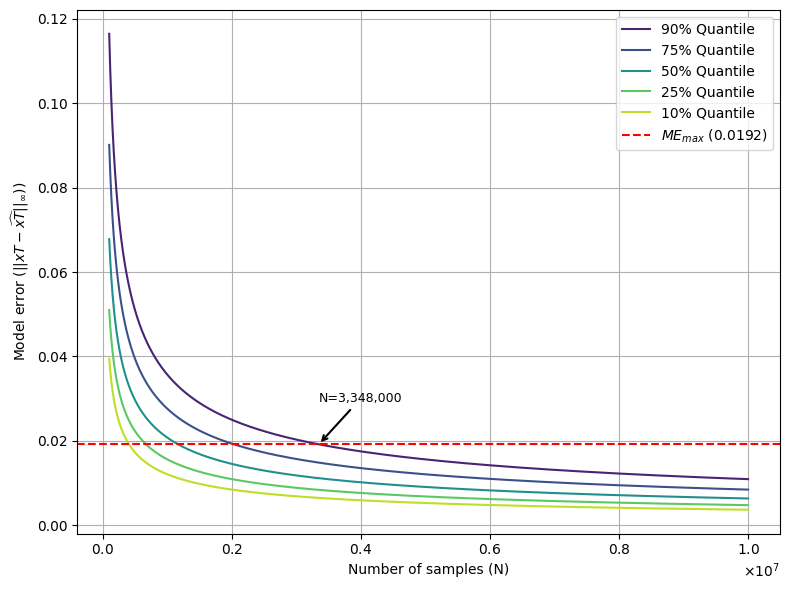

In [65]:
plt.figure(figsize=(8, 6))

# Define the quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if not desired_certainty in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

# Plot the quantiles
for q in quantiles:
    qs = lognorm.ppf(q, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(Ns))))
    plt.plot(Ns, qs, label=f'{int(q*100)}% Quantile', color=cm.viridis_r(q))

qs = lognorm.ppf(desired_certainty, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(Ns))))

# Get the index of the largest M below max_max_error
index = np.argwhere(qs < max_acceptable_error)[:-1][0]
# Get the corresponding M, nx, and ny values
N = Ns[index]
print(f"Min N with acceptable error: {N}")

# Annotate the largest N below max_max_error
plt.annotate(f'N={int(N):,}', xy=(N, qs[index]), xytext=(N, qs[index]+0.01),
             arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black')

# Add horizontal line at max_max_error
plt.axhline(y=max_acceptable_error, color='red', linestyle='--', label=rf'$ME_{{max}}$ ({max_acceptable_error:.4f})')
plt.xlabel('Number of samples (N)')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
plt.ylabel('Model error ($||xT-\widehat{xT}||_{\infty})$)')
# plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
# plt.xticks(Ms, rotation=90)
plt.show()


In [66]:
N

array([3348000])

In [67]:
print(f"This corresponds to approximately {N[0]/620_000:.3f} seasons of data.")

This corresponds to approximately 5.400 seasons of data.


# Expected Threat models for the found values

In [71]:
import sys
import pandas as pd

sys.path.append("../")
from xThreat import xThreat

In [73]:
data_path = '../1-data-preparation/data-storage/xThreat_data_v4.parquet'
df_events = pd.read_parquet(data_path, engine='fastparquet')
df_events['shot'] = ~df_events['shot_outcome'].isna()
df_events['goal'] = df_events['shot_outcome'] == 'Goal'
df_events.drop(columns=['id', 'shot_outcome', 'possession'], inplace=True)
df_size_bytes = df_events.memory_usage(deep=True).sum()
df_size_mb = df_size_bytes / (1024 ** 2)  # Convert to MB

print(f"DataFrame size: {df_size_mb:.2f} MB")

DataFrame size: 1039.54 MB


## For finding the grid for the data set size

In [79]:
df_N_2_480_000 = df_events.head(2_480_000).copy()
xT_10x8_N_2_480_000 = xThreat(n_x=10, n_y=8)
xT_10x8_N_2_480_000.fit(df_N_2_480_000)

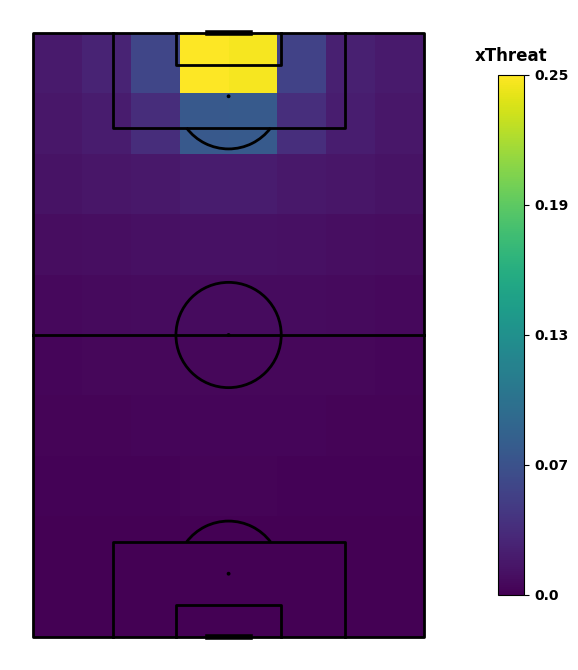

In [81]:
xT_10x8_N_2_480_000.plot_xThreat(cmap='viridis')

## For finding the data set size for grid size

In [80]:
df_N_3_350_000 = df_events.head(3_350_000).copy()
xT_16x12_N_3_350_000 = xThreat(n_x=16, n_y=12)
xT_16x12_N_3_350_000.fit(df_N_3_350_000)

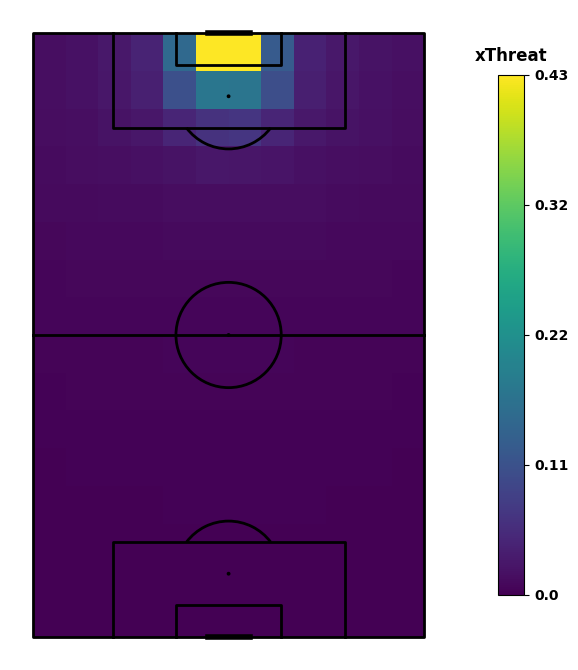

In [77]:
xT_16x12_N_3_350_000.plot_xThreat(cmap='viridis')